# Vecchia 3D parameter estimation using maximum likelihood estimation

This example will cover:
 - Using the Vecchia approximation for drawing prior samples, inferring parameters and making predictions
 - Use maximum likelihood estimation to optimise kernel parameters

Code is heavily borrowed from github.com/mingdeyu/DGP

***GPVecchia uses `numba` so it is slow to run the first time.***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from gptide.gpscipy import GPtideScipy
from gptide import mle

### Generate some 3D data

In [2]:
# Create some data coordinates
np.random.seed(0)

# Number of data points
totp = 500

# spatial coords
xs = ys = zs = 15
X = np.column_stack((np.random.randint(0, xs, totp),
                     np.random.randint(0, ys, totp),
                     np.random.randint(0, zs, totp))).astype(np.float64)
Xix = np.argsort(X[:,0])
X = X[Xix] # Data would generally come sorted along one dimension - Vecchia will do some re-ordering

print(X.shape)
print(xs*ys*zs)

(500, 3)
3375


In [20]:
# Example mean func
def my_mean(x, mean):
    return np.ones(x.shape[0]) * mean

from scipy.spatial.distance import cdist
def matern32_matrix_numba(x1, x2, cp):
    gp_std, lx, ly, lz = cp
    Xsc = x1 / np.array([lx, ly, lz])
    Xprsc = x2.T / np.array([lx, ly, lz])
    fac1 = 3*(cdist(Xsc, Xprsc))**2
    fac2 = np.sqrt(fac1)
    return (gp_std**2 * (1 + fac2)*np.exp(-fac2))

In [21]:
# These are our kernel input parameters
gp_noise = 0.1
gp_std = 0.5
xl = 3
yl = 9
zl = 13

# GPVecchia parameters
n_neighbours = 30 # number of neighbours to use
cov_func = matern32_matrix_numba
cov_params = (gp_std, xl, yl, zl)
mean_func = my_mean
mean_params = 20.0

### Object initialisation

In [22]:
gp_vec = GPtideScipy(X, 
                     X.copy(),
                     gp_noise, 
                     cov_func, 
                     cov_params,
                     mean_func=mean_func,
                     mean_params=mean_params)


### Draw from the prior

In [26]:
n_samp = 1
smp_prior = gp_vec.prior(samples=n_samp)

print(smp_prior.shape)

(500, 500)


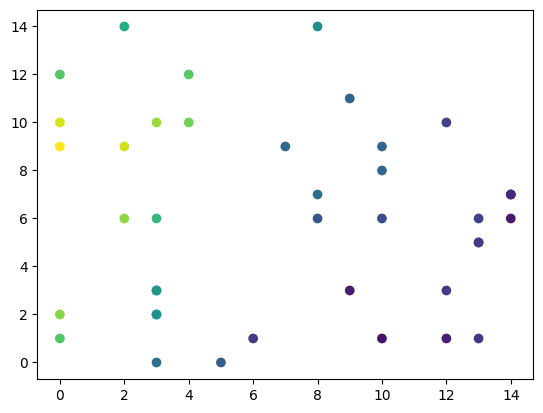

In [28]:
idx = X[:,-1] == 0
plt.scatter(X[:,0][idx], X[:,1][idx], c=np.diag(smp_prior)[idx], cmap='viridis')

### Evaluate the log-likelihood
Just using the true parameters here.

In [29]:
# Make one of the prior samples the input observations
y = smp_prior

sm_std = np.std(y - np.mean(y))
print(f'Small scale std dev.: {sm_std:.4}')
print(f'Mean: {np.mean(y):.4}')

tstart = time.time()
loglike = gp_vec.log_marg_likelihood(y)
ll_time = time.time() - tstart
print(f'Log likelihood computed in {ll_time:.3f} seconds')
print(loglike)

Small scale std dev.: 0.5118
Mean: 20.09
Log likelihood computed in 0.052 seconds
240.64278303464312


## MLE 

Try to infer the hyperparameters using maximum likelihood estimation. 

Will set the tolerance high because log-likelihood is a large number.

Didn't have much luck with gradient based methods, but there is an analytical form for the log-likelihood gradient which Ming has implemented (we could add).

In [ ]:
# Initial guess of the noise and covariance parameters (these can matter)
noise_ic = 0.15
covparams_ic = [0.4, 5., 5., 16.]
meanparams_ic = [18.]
# bnds = ((1e-5, 1e3), (1e-3, 1e3), (1e-3, 1e3), (1e-3, 1e3), (1e-3, 1e3), (1e-3, 1e3))

soln = mle(
    X,
    y,
    cov_func,
    covparams_ic,
    noise_ic,
    meanfunc=mean_func,
    meanparams_ic=meanparams_ic,
    # method='Nelder-Mead',
    GPclass=GPtideScipy,
    # gp_kwargs={'order_func':order_func, 'order_params':order_params, 'nn_kwargs':nn_kwargs},
    bounds=None,
    verbose=False)


print('Noise (true): {:3.4f}, |Noise| (mle): {:3.4f}'.format(gp_noise, soln['x'][0]))
print('η (true): {:3.3f}, η (mle): {:3.3f}'.format(sm_std, soln['x'][1]))
print('ℓx (true): {:3.2f}, ℓx (mle): {:3.2f}'.format(cov_params[1], soln['x'][2]))
print('ℓy (true): {:3.2f}, ℓy (mle): {:3.2f}'.format(cov_params[2], soln['x'][3]))
print('ℓt (true): {:3.2f}, ℓt (mle): {:3.2f}'.format(cov_params[3], soln['x'][4]))
print('mean (true): {:3.2f}, mean (mle): {:3.2f}'.format(np.mean(y), soln['x'][5]))

Does ok, some issues finding noise and variance together for sparse data like this. Data with some close points should work better. 

### Evaluating the likelihood gradient

***Not implemented yet***

## Conditioning on data

Mean and variance predictions 

In [11]:
x_pred = np.linspace(0, xs, 50)
y_pred = np.linspace(0, ys, 50)
z_pred = np.linspace(0, zs, 20)

# Prediction points dont need to be randomly ordered
xx_grid, yy_grid, zz_grid = np.meshgrid(x_pred, y_pred, z_pred, indexing='ij')
X_pred = np.column_stack((xx_grid.ravel(), yy_grid.ravel(), zz_grid.ravel())).astype(np.float64)
print(X_pred.shape)

(50000, 3)


In [12]:
gp_vec = GPtideVecchia(X, 
                       X_pred,
                       gp_noise, 
                       cov_func, 
                       cov_params,
                       mean_func=mean_func, mean_params=mean_params,
                       order_func=order_func, order_params=order_params,
                       nnum=n_neighbours, nn_kwargs=nn_kwargs)

tstart = time.time()
y_mean, y_uq = gp_vec(y)
cnd_time = time.time() - tstart

print(f'Conditioning completed in {cnd_time:.2f} seconds')
print(y_mean.shape)
print('Pred variance:', np.var(y_mean - np.mean(y_mean)))
print(y_uq.shape)

Conditioning completed in 10.10 seconds
(50000,)
Pred variance: 0.20886186528440082
(50000,)


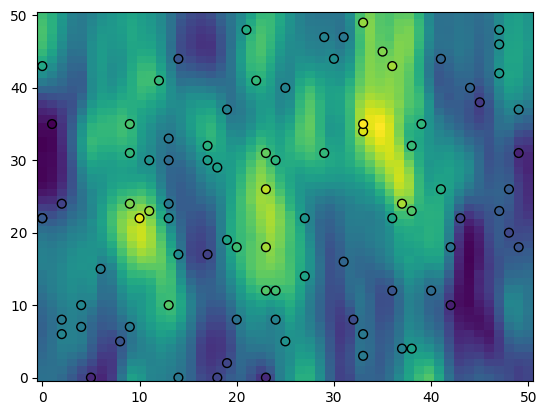

In [13]:
plt.pcolormesh(xx_grid[:,:,0], yy_grid[:,:,0], y_mean.reshape(xx_grid.shape)[:,:,0], cmap='viridis')

idx = X[:,-1] == 0
plt.scatter(X[:,0][idx], X[:,1][idx], c=y[idx], cmap='viridis', ec='k', s=40)

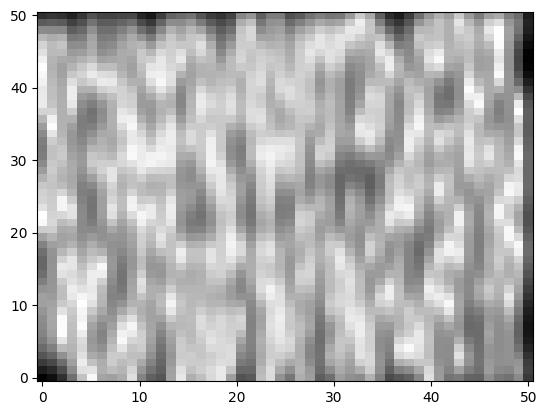

In [14]:
plt.pcolormesh(xx_grid[:,:,0], yy_grid[:,:,0], y_uq.reshape(xx_grid.shape)[:,:,0], cmap='gray_r')

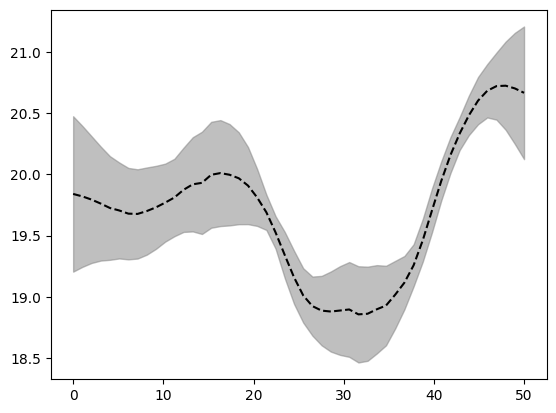

In [15]:
plt.plot(xx_grid[:,0,0], y_mean.reshape(xx_grid.shape)[0,:,0], 'k--')
plt.fill_between(xx_grid[:,0,0],
                 y_mean.reshape(xx_grid.shape)[0,:,0] - 2*y_uq.reshape(xx_grid.shape)[0,:,0],\
                 y_mean.reshape(xx_grid.shape)[0,:,0] + 2*y_uq.reshape(xx_grid.shape)[0,:,0],\
                 color='gray', alpha=0.5)